# OpenFDA — Data Collection & EDA

## Background

The OpenFDA API is maintained by the U.S. Food and Drug Administration and provides regulatory and safety information on approved drugs and biologics via the Drugs@FDA database. Each record contains application metadata (NDA/ANDA/BLA), sponsor name, generic and brand names, marketing status, therapeutic drug class (EPC), mechanism of action, route of administration, and approval year. These fields enrich drug-intervention trials with regulatory context that is independent of the trial's own design.

## Purpose of This Notebook

This notebook covers **collection, preprocessing, and exploratory analysis** of the OpenFDA dataset before it is joined with ClinicalTrials.gov records. Key steps:

1. **Data collection** — fetched from the OpenFDA Drugs@FDA endpoint; raw JSON stored per application record
2. **Field extraction** — application type, approval year, sponsor, drug names, therapeutic class, marketing status, route, and dosage form parsed from nested JSON
3. **Preprocessing** — string normalization, deduplication on application number + drug name, missing-value audit
4. **EDA** — application type distribution, marketing status breakdown, approval trends over time, top sponsors, and top therapeutic classes

The processed output (`openfda_processed.parquet`) is used in `Join_and_Preprocess.ipynb` as the FDA-side table for fuzzy drug-name joining against ClinicalTrials.gov trial records.

**Dataset size:** 12,344 FDA drug application records × 21 columns

### Imports

In [1]:
import json
from pathlib import Path
from datetime import datetime
from collections import Counter

import polars as pl
import matplotlib.pyplot as plt

In [2]:
RAW_DATA_DIR = Path("data/raw")
INTERIM_DATA_DIR = Path("data/interim")
PROCESSED_DATA_DIR = Path("data/processed")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

### Load unprocessed CSV

In [3]:
raw_csv_path = INTERIM_DATA_DIR / "openfda_raw_unprocessed.csv"
raw_df = pl.read_csv(raw_csv_path)

print(raw_df.shape)
raw_df.head()

raw_records = [json.loads(x) for x in raw_df["raw_json"].to_list()]

print(f"Loaded {len(raw_records)} raw records")
print(raw_records[0].keys())

(12344, 2)
Loaded 12344 raw records
dict_keys(['submissions', 'application_number', 'sponsor_name', 'openfda', 'products'])


### Pass JSON into Python records

In [4]:
raw_records = [json.loads(x) for x in raw_df["raw_json"].to_list()]

print(f"Loaded {len(raw_records)} raw records")
print(raw_records[0].keys())

Loaded 12344 raw records
dict_keys(['submissions', 'application_number', 'sponsor_name', 'openfda', 'products'])


In [5]:
def first_or_none(value):
    if isinstance(value, list) and len(value) > 0:
        return value[0]
    return None

### Extract Data

In [6]:
def extract_drugsfda_record(record):
    application_number = record.get("application_number")
    submissions = record.get("submissions", [])
    products = record.get("products", [])
    openfda = record.get("openfda", {})

    first_submission = submissions[0] if submissions else {}
    first_product = products[0] if products else {}

    submission_date = first_submission.get("submission_status_date")
    approval_year = int(submission_date[:4]) if submission_date else None

    application_type = None
    if application_number:
        if application_number.startswith("NDA"):
            application_type = "NDA"
        elif application_number.startswith("ANDA"):
            application_type = "ANDA"
        elif application_number.startswith("BLA"):
            application_type = "BLA"
        else:
            application_type = "OTHER"

    return {
        "application_number": application_number,
        "application_type": application_type,
        "sponsor_name": record.get("sponsor_name"),
        "generic_name": first_or_none(openfda.get("generic_name")),
        "brand_name": first_or_none(openfda.get("brand_name")),
        "manufacturer_name": first_or_none(openfda.get("manufacturer_name")),
        "marketing_status": first_product.get("marketing_status"),
        "therapeutic_class_epc": first_or_none(openfda.get("pharm_class_epc")),
        "therapeutic_class_cs": first_or_none(openfda.get("pharm_class_cs")),
        "mechanism_of_action": first_or_none(openfda.get("pharm_class_moa")),
        "regulatory_action_type": first_submission.get("submission_status"),
        "submission_type": first_submission.get("submission_type"),
        "review_priority": first_submission.get("review_priority"),
        "approval_year": approval_year,
        "submission_status_date": submission_date,
        "product_type": first_or_none(openfda.get("product_type")),
        "route": first_product.get("route"),
        "dosage_form": first_product.get("dosage_form"),
        "substance_name": first_or_none(openfda.get("substance_name")),
        "rxcui": first_or_none(openfda.get("rxcui")),
        "unii": first_or_none(openfda.get("unii")),
    }

### Extract All Rows

In [7]:
rows = [extract_drugsfda_record(record) for record in raw_records]
df = pl.DataFrame(rows)

print(df.shape)
df.head()

(12344, 21)


application_number,application_type,sponsor_name,generic_name,brand_name,manufacturer_name,marketing_status,therapeutic_class_epc,therapeutic_class_cs,mechanism_of_action,regulatory_action_type,submission_type,review_priority,approval_year,submission_status_date,product_type,route,dosage_form,substance_name,rxcui,unii
str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str
"""ANDA090763""","""ANDA""","""MYLAN PHARMS INC""","""LANSOPRAZOLE""","""LANSOPRAZOLE""","""Mylan Pharmaceuticals Inc.""","""Prescription""","""Proton Pump Inhibitor [EPC]""",null,"""Proton Pump Inhibitors [MoA]""","""AP""","""SUPPL""","""STANDARD""",2015,"""20150316""","""HUMAN PRESCRIPTION DRUG""","""ORAL""","""CAPSULE, DELAYED REL PELLETS""","""LANSOPRAZOLE""","""311277""","""0K5C5T2QPG"""
"""ANDA091099""","""ANDA""","""HIKMA""","""IMIPRAMINE PAMOATE""","""IMIPRAMINE PAMOATE""","""Hikma Pharmaceuticals USA Inc""","""Prescription""",null,null,null,"""AP""","""SUPPL""","""STANDARD""",2016,"""20160202""","""HUMAN PRESCRIPTION DRUG""","""ORAL""","""CAPSULE""","""IMIPRAMINE PAMOATE""","""835572""","""MC34P30298"""
"""ANDA090097""","""ANDA""","""DR REDDYS LABS SA""","""LIOTHYRONINE SODIUM""","""LIOTHYRONINE SODIUM""","""Dr. Reddy's Labratories Inc.""","""Prescription""",null,null,null,"""AP""","""SUPPL""","""STANDARD""",2019,"""20191217""","""HUMAN PRESCRIPTION DRUG""","""ORAL""","""TABLET""","""LIOTHYRONINE SODIUM""","""903456""","""GCA9VV7D2N"""
"""ANDA076186""","""ANDA""","""UPSHER SMITH LABS""","""AMANTADINE HYDROCHLORIDE""","""AMANTADINE HYDROCHLORIDE""","""Upsher-Smith Laboratories, LLC""","""Prescription""",null,null,null,"""AP""","""SUPPL""","""STANDARD""",2025,"""20250710""","""HUMAN PRESCRIPTION DRUG""","""ORAL""","""TABLET""","""AMANTADINE HYDROCHLORIDE""","""849395""","""M6Q1EO9TD0"""
"""ANDA077321""","""ANDA""","""LUPIN""","""LISINOPRIL""","""LISINOPRIL""","""Quallent Pharmaceuticals Healt…","""Prescription""",null,null,null,"""AP""","""SUPPL""","""STANDARD""",2020,"""20200427""","""HUMAN PRESCRIPTION DRUG""","""ORAL""","""TABLET""","""LISINOPRIL""","""197884""","""E7199S1YWR"""


### Basic Pre-processing

In [8]:
df_clean = (
    df
    .with_columns([
        pl.col("application_type").cast(pl.Utf8),
        pl.col("marketing_status").cast(pl.Utf8),
        pl.col("therapeutic_class_epc").cast(pl.Utf8),
        pl.col("route").cast(pl.Utf8),
        pl.col("dosage_form").cast(pl.Utf8),
        pl.col("review_priority").cast(pl.Utf8),
        pl.col("approval_year").cast(pl.Int64, strict=False),
    ])
    .with_columns([
        pl.col("application_type").str.strip_chars().str.to_uppercase(),
        pl.col("marketing_status").str.strip_chars(),
        pl.col("route").str.strip_chars().str.to_uppercase(),
        pl.col("dosage_form").str.strip_chars().str.to_uppercase(),
        pl.col("review_priority").str.strip_chars().str.to_uppercase(),
    ])
)

### Remove duplicates

In [9]:
df_clean = df_clean.unique(subset=["application_number", "brand_name", "generic_name"])
print(df_clean.shape)

(12344, 21)


In [10]:
missing_df = pl.DataFrame({
    "column": df_clean.columns,
    "null_count": [df_clean[col].null_count() for col in df_clean.columns],
    "n_rows": [df_clean.height for _ in df_clean.columns]
}).with_columns(
    (pl.col("null_count") / pl.col("n_rows") * 100).alias("null_percent")
).sort("null_percent", descending=True)

missing_df

column,null_count,n_rows,null_percent
str,i64,i64,f64
"""therapeutic_class_cs""",10115,12344,81.942644
"""mechanism_of_action""",9251,12344,74.943292
"""therapeutic_class_epc""",7160,12344,58.003889
"""review_priority""",2566,12344,20.787427
"""rxcui""",362,12344,2.932599
…,…,…,…
"""brand_name""",0,12344,0.0
"""manufacturer_name""",0,12344,0.0
"""regulatory_action_type""",0,12344,0.0


### Exploratory Data Analysis

In [11]:
app_type_counts = (
    df_clean
    .group_by("application_type")
    .len()
    .sort("len", descending=True)
)

app_type_counts

application_type,len
str,u32
"""ANDA""",9348
"""NDA""",2616
"""BLA""",380


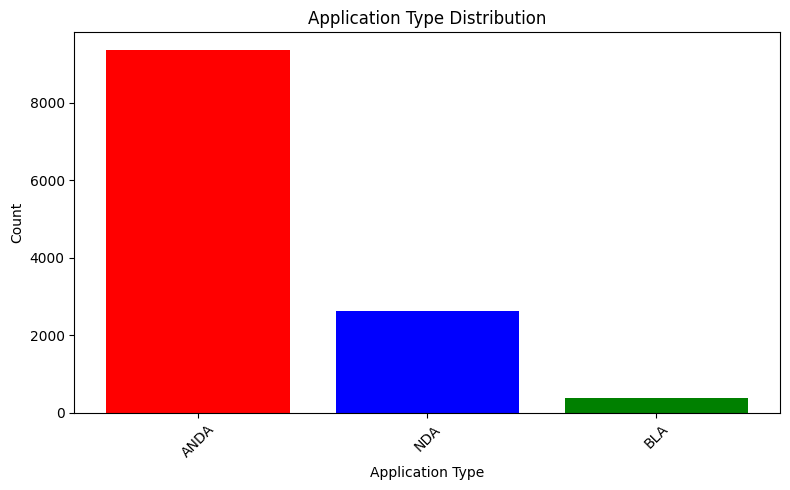

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(app_type_counts["application_type"].to_list(), app_type_counts["len"].to_list(), color=["red","blue","green"])
plt.xlabel("Application Type")
plt.ylabel("Count")
plt.title("Application Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
marketing_counts = (
    df_clean
    .filter(pl.col("marketing_status").is_not_null())
    .group_by("marketing_status")
    .len()
    .sort("len", descending=True)
)

marketing_counts

marketing_status,len
str,u32
"""Prescription""",11000
"""Discontinued""",815
"""Over-the-counter""",514
"""None (Tentative Approval)""",14


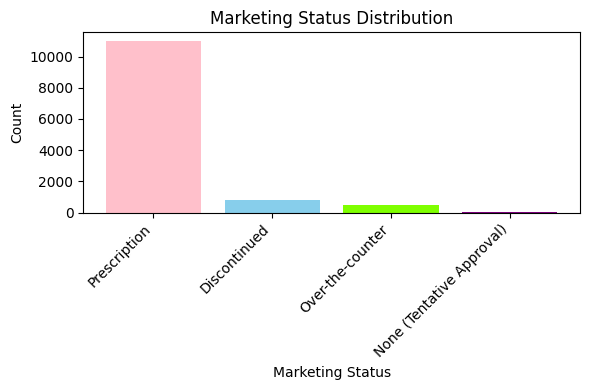

In [27]:
plt.figure(figsize=(6,4))
plt.bar(marketing_counts["marketing_status"].to_list(), marketing_counts["len"].to_list(),
        color=["pink","skyblue","chartreuse","purple"])
plt.xlabel("Marketing Status")
plt.ylabel("Count")
plt.title("Marketing Status Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
year_app_counts = (
    df_clean
    .filter(pl.col("approval_year").is_not_null(), pl.col("application_type").is_not_null())
    .group_by(["approval_year", "application_type"])
    .len()
    .sort(["approval_year", "application_type"])
)

year_app_counts.head()

approval_year,application_type,len
i64,str,u32
1947,"""NDA""",1
1954,"""NDA""",1
1959,"""NDA""",1
1964,"""NDA""",2
1965,"""BLA""",1


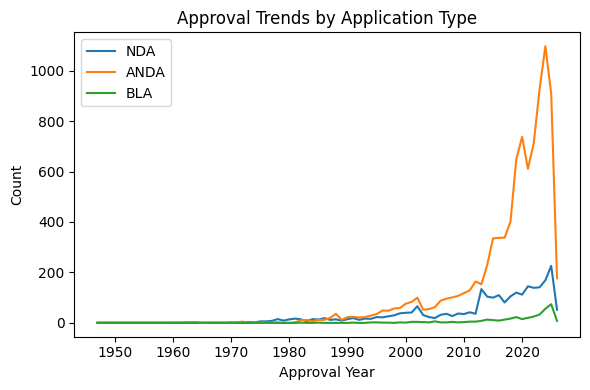

In [24]:
pivot_df = (
    df_clean
    .filter(pl.col("approval_year").is_not_null(), pl.col("application_type").is_not_null())
    .group_by(["approval_year", "application_type"])
    .len()
    .pivot(values="len", index="approval_year", on="application_type")
    .sort("approval_year")
    .fill_null(0)
)

years = pivot_df["approval_year"].to_list()

plt.figure(figsize=(6, 4))

for col in pivot_df.columns[1:]:
    plt.plot(years, pivot_df[col].to_list(), label=col)

plt.xlabel("Approval Year")
plt.ylabel("Count")
plt.title("Approval Trends by Application Type")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
top_sponsors = (
    df_clean
    .filter(pl.col("sponsor_name").is_not_null())
    .group_by("sponsor_name")
    .len()
    .sort("len", descending=True)
    .head(15)
)

top_sponsors

sponsor_name,len
str,u32
"""HIKMA""",259
"""FRESENIUS KABI USA""",250
"""AUROBINDO PHARMA LTD""",220
"""AUROBINDO PHARMA""",206
"""ALEMBIC""",191
…,…
"""MACLEODS PHARMS LTD""",138
"""ZYDUS PHARMS""",136
"""DR REDDYS""",131


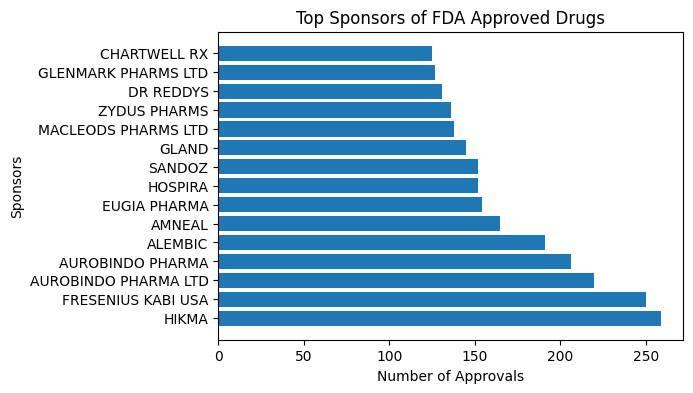

In [23]:
plt.figure(figsize=(6, 4))
plt.barh(top_sponsors["sponsor_name"], top_sponsors["len"])
plt.title("Top Sponsors of FDA Approved Drugs")
plt.ylabel("Sponsors")
plt.xlabel("Number of Approvals")
plt.show()

In [28]:
top_classes = (
    df_clean
    .filter(pl.col("therapeutic_class_epc").is_not_null())
    .group_by("therapeutic_class_epc")
    .len()
    .sort("len", descending=True)
    .head(15)
)

top_classes

therapeutic_class_epc,len
str,u32
"""Corticosteroid [EPC]""",310
"""Nonsteroidal Anti-inflammatory…",233
"""Anti-epileptic Agent [EPC]""",129
"""Thiazide Diuretic [EPC]""",124
"""Atypical Antipsychotic [EPC]""",117
…,…
"""Kinase Inhibitor [EPC]""",81
"""Angiotensin 2 Receptor Blocker…",74
"""Radioactive Diagnostic Agent […",73


In [29]:
top_classes[:10]

therapeutic_class_epc,len
str,u32
"""Corticosteroid [EPC]""",310
"""Nonsteroidal Anti-inflammatory…",233
"""Anti-epileptic Agent [EPC]""",129
"""Thiazide Diuretic [EPC]""",124
"""Atypical Antipsychotic [EPC]""",117
"""Azole Antifungal [EPC]""",115
"""Benzodiazepine [EPC]""",112
"""Retinoid [EPC]""",106
"""Nucleoside Metabolic Inhibitor…",95


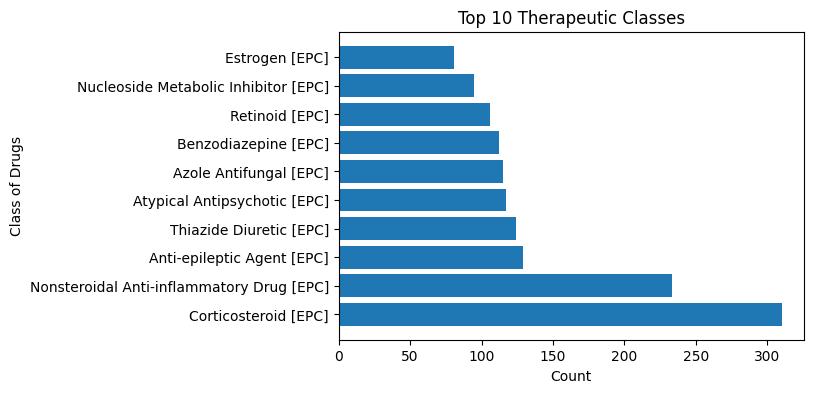

In [30]:
plt.figure(figsize=(6,4))
plt.barh(top_classes[:10]["therapeutic_class_epc"], top_classes[:10]["len"])
plt.title("Top 10 Therapeutic Classes")
plt.xlabel("Count")
plt.ylabel("Class of Drugs")
plt.show()

In [31]:
processed_csv_path = Path("data/openfda_processed.csv")
processed_parquet_path = PROCESSED_DATA_DIR / "openfda_processed.parquet"

df_clean.write_csv(processed_csv_path)
df_clean.write_parquet(processed_parquet_path)

print(f"Saved processed CSV to {processed_csv_path}")
print(f"Saved processed Parquet to {processed_parquet_path}")

Saved processed CSV to ..\data\processed\openfda_processed.csv
Saved processed Parquet to ..\data\processed\openfda_processed.parquet
